# 01 · Grouping check

**Question:** will the models do the grouping task at all? That means taking 40 photos in one message and returning a valid grouping, as a check before the pre-registered study.

**Subjects:** Annie Lööf and Maria Ohisalo, 20 photos each, from Wikimedia Commons. (Sofie Carsten Nielsen was dropped: almost all of her Commons photos come from one 2011 campaign album.)

**Steps**
1. Commons metadata for both subjects into one table.
2. Filter (width ≥ 800 px, licence present). Sample 60 Lööf photos and keep all of Ohisalo's.
3. Download the originals to `data/raw/` and check them against Commons' SHA-1.
4. Contact sheets, then pick 20 per subject by eye.
5. Make stimuli (upright, 512 px, no EXIF), shuffle with a fixed seed, and save `order.csv`.
6. Call the 5 models (full photos).
7. Head crops (YuNet), checked by eye, then call the 5 models again on the crops.

**Outputs** (`data/check/`): `candidates.csv`, `picks.csv`, `order.csv`, `responses.csv`, `crops.csv`, `responses_crops.csv`, and the contact sheets.

**Result (one call per model and condition, so not a finding):** all 5 models do the task. Full photos: 3 perfect, 2 misplaced one photo each. Head crops: 4 perfect; GPT-5.6 Sol split each woman into 2 groups. The picks have known cues (party versus government backdrops, hair colour, a few photos with several people), which is why the main study has the head-crop condition and fresh picks.

**Reading a model's answer:** the numbers in a model's answer are **positions** ("Photo 1" … "Photo 40"), not row numbers. Join them to `order.csv` to get the photo and the subject.

In [24]:
from pathlib import Path
import json, random
import pandas as pd
from facesort import commons, openrouter
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
SUBJECTS = {"loof": "Annie Lööf", "ohisalo": "Maria Ohisalo"}

## 1 · Commons metadata for both subjects

In [25]:
frames = []
for key, name in SUBJECTS.items():
    df = pd.DataFrame(commons.image_info(commons.category_jpegs(name)))
    df['subject'] = key
    frames.append(df)
result_df = pd.concat(frames, ignore_index=True)
assert result_df['subject'].notna().all(), "some rows have no subject"
result_df['subject'].value_counts()

subject
loof       834
ohisalo    107
Name: count, dtype: int64

## 2 · Filter and sample
Lööf has ~820 usable photos, so 60 are sampled at random (seed 0). Ohisalo has ~100, so all of them are reviewed.

In [26]:
filtered_res = result_df[(result_df['width']>=800) & (result_df['licence'].notna())]

# Lööf has ~820 photos, so review a random 60; Ohisalo has ~100, so review all of them.
loof_sample = filtered_res[filtered_res['subject'] == 'loof'].groupby('subject').sample(n=60, random_state=0)
ohisalo_all = filtered_res[filtered_res['subject'] == 'ohisalo']
sample_df = pd.concat([loof_sample, ohisalo_all])

assert len(loof_sample) == 60
assert len(ohisalo_all) == (filtered_res['subject'] == 'ohisalo').sum()
sample_df['subject'].value_counts()

subject
ohisalo    104
loof        60
Name: count, dtype: int64

## 3 · Download the originals
Files are named by SHA-1 and checked against Commons. Files already on disk are skipped, so a rerun is cheap.

In [27]:
RAW = Path("../data/raw")

raw_paths = []
for i, row in enumerate(sample_df.itertuples(), start=1):
    dest = RAW / row.subject / f"{row.sha1}.jpg"
    raw_paths.append(commons.download(row.url, dest, row.sha1))
    if i % 10 == 0:
        print(f"{i}/{len(sample_df)} downloaded")

sample_df["raw_path"] = [str(p) for p in raw_paths]
Path("../data/check").mkdir(parents=True, exist_ok=True)
sample_df.to_csv("../data/check/candidates.csv", index=False)
print("done:", sample_df["subject"].value_counts().to_dict())

10/164 downloaded
20/164 downloaded
30/164 downloaded
40/164 downloaded
50/164 downloaded
60/164 downloaded
70/164 downloaded
80/164 downloaded
90/164 downloaded
100/164 downloaded
110/164 downloaded
120/164 downloaded
130/164 downloaded
140/164 downloaded
150/164 downloaded
160/164 downloaded
done: {'ohisalo': 104, 'loof': 60}


## Matplotlib practice (scratch)
One photo, then a small grid. These cells only build up to the contact sheet below, and nothing later depends on them.

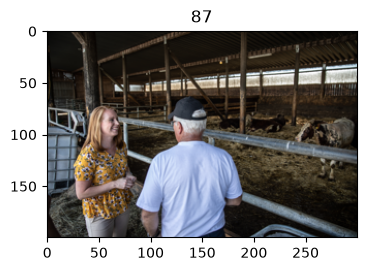

In [28]:
row = next(sample_df.itertuples())      # first row, as a named tuple

fig, ax = plt.subplots(figsize=(4, 4))

img = Image.open(row.raw_path)
img = ImageOps.exif_transpose(img)      # turn it upright
img.thumbnail((300, 300))               # shrink it (changes img in place, returns None)

ax.imshow(img)
ax.set_title(row.Index)
plt.show()

(2, 3)


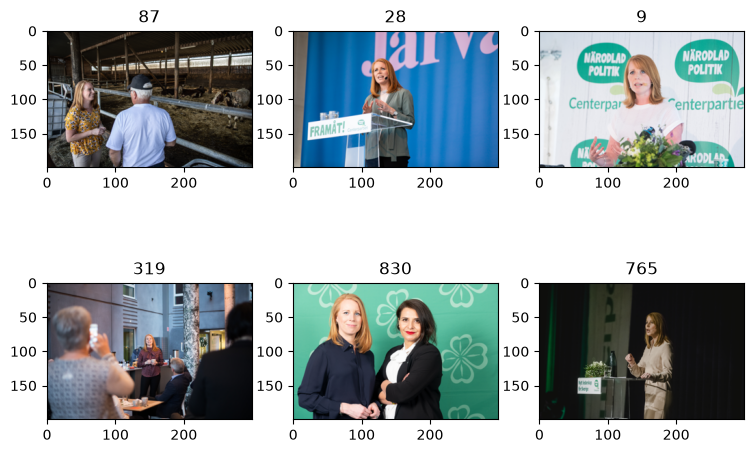

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(9,6))
print(axes.shape)

for ax, row in zip(axes.flat, sample_df.head(6).itertuples()):
    img = Image.open(row.raw_path)
    img = ImageOps.exif_transpose(img)      # turn it upright
    img.thumbnail((300, 300))               # shrink it (changes img in place, returns None)
    
    ax.imshow(img)
    ax.set_title(row.Index)
plt.show()

## 4 · Contact sheets
Each photo is labelled with its row number and date. Pick 20 per subject from these sheets.

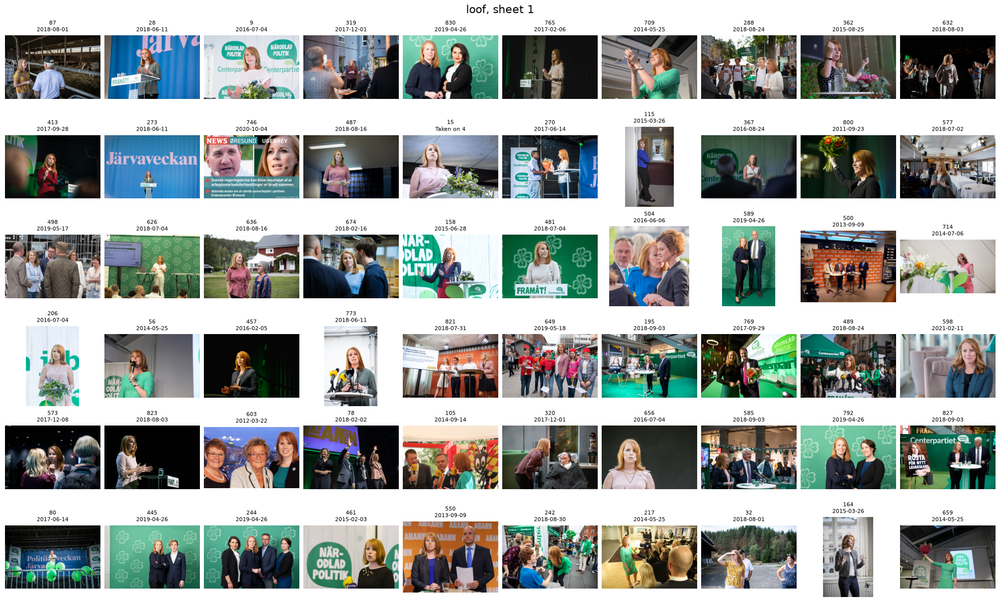

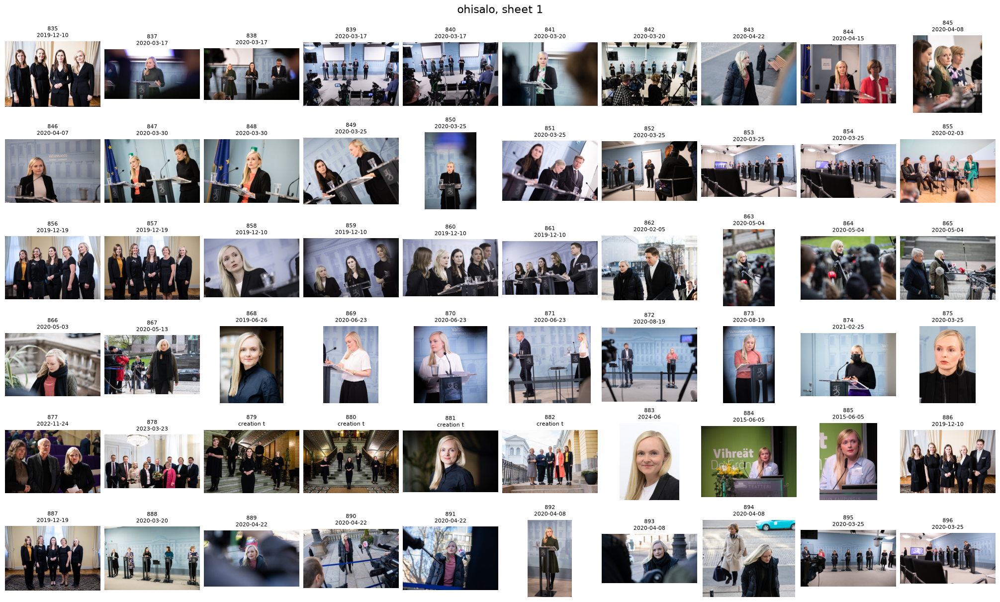

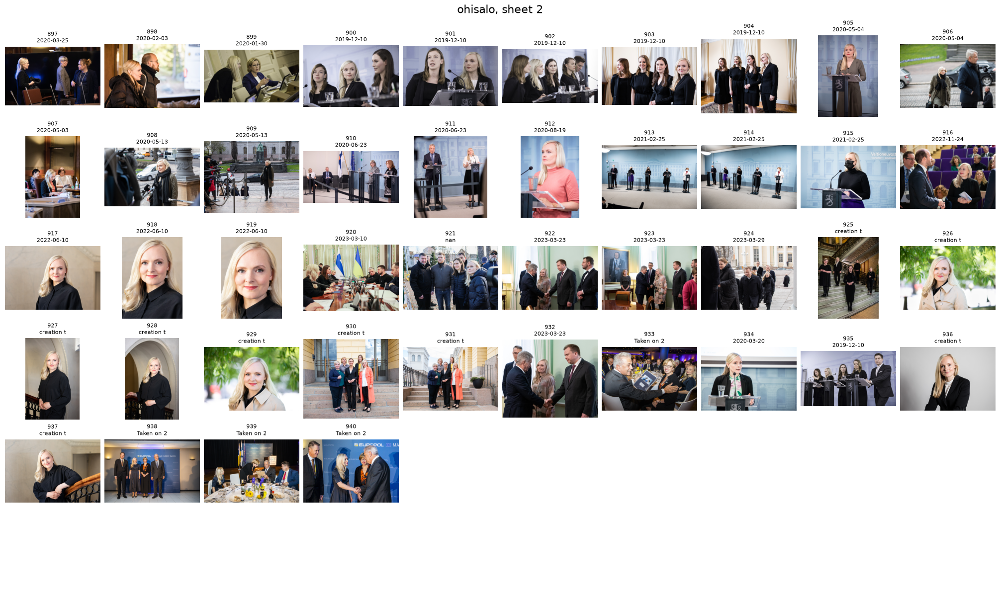

In [30]:
PER_SHEET = 60

for subject, df in sample_df.groupby("subject"):
    for part, start in enumerate(range(0, len(df), PER_SHEET), start=1):
        chunk = df.iloc[start:start + PER_SHEET]
        fig, axes = plt.subplots(6, 10, figsize=(20, 12), layout="constrained")

        for ax in axes.flat:
            ax.axis("off")

        for ax, row in zip(axes.flat, chunk.itertuples()):
            img = Image.open(row.raw_path)
            img = ImageOps.exif_transpose(img)
            img.thumbnail((300, 300))
            ax.imshow(img)
            ax.set_title(f"{row.Index}\n{str(row.date_taken)[:10]}", fontsize=8)

        fig.suptitle(f"{subject}, sheet {part}", fontsize=16)
        fig.savefig(f"../data/check/sheet_{subject}_{part}.jpg", dpi=100)
        plt.show()

## 5 · The picks
The row numbers come from the sheets above. They are only stable while `data/cache/` is unchanged (they depend on Commons search order). `picks.csv`, keyed by SHA-1, is the durable record.

In [31]:
keep_loof = [28, 9, 830, 765, 709, 362, 413, 487, 15, 115, 367, 800, 577, 626, 481, 714, 206, 56, 457, 773]
keep_ohisalo = [837, 841, 843, 844, 846, 848, 850, 858, 863, 866, 867, 868, 869, 870, 873, 875, 881, 883, 885, 912]

PICKS = Path("../data/check/picks.csv")

if PICKS.exists():
    # Row numbers depend on Commons search order, so once saved, picks are matched by SHA-1.
    saved = pd.read_csv(PICKS, index_col=0)
    row_of = pd.Series(sample_df.index, index=sample_df["sha1"])
    picks = sample_df.loc[row_of[saved["sha1"]].values]
else:
    picks = sample_df.loc[keep_loof + keep_ohisalo]
    picks.to_csv(PICKS)

assert len(picks) == 40 and picks["sha1"].is_unique, "need 40 distinct photos"
assert picks["subject"].value_counts().to_dict() == {"loof": 20, "ohisalo": 20}
picks["subject"].value_counts()

subject
loof       20
ohisalo    20
Name: count, dtype: int64

## 6 · Stimuli, order and model calls (full photos)

In [32]:
# Resize the 40 picks to stimuli: upright, RGB, longest side 512px, JPEG q85, no EXIF.
STIM = Path("../data/check/stimuli")
STIM.mkdir(parents=True, exist_ok=True)

stim_paths = []
for row in picks.itertuples():
    img = Image.open(row.raw_path)
    img = ImageOps.exif_transpose(img)      # apply the rotation before EXIF is dropped
    img = img.convert("RGB")
    img.thumbnail((512, 512))
    out = STIM / f"{row.sha1}.jpg"
    img.save(out, "JPEG", quality=85)       # PIL writes no EXIF unless you pass exif=
    stim_paths.append(str(out))

picks["stim_path"] = stim_paths
assert len(list(STIM.glob("*.jpg"))) == 40

In [33]:
# Shuffle once with a fixed seed and record which photo sits at which position.
# order.csv is the only link between "Photo 7" in a model's answer and a real photo.
order = (
    picks.reset_index(names="row")[["row", "subject", "sha1", "stim_path"]]
    .sample(frac=1, random_state=0)
    .reset_index(drop=True)
)
order.insert(0, "position", range(1, len(order) + 1))
order.to_csv("../data/check/order.csv", index=False)

paths_in_order = [Path(p) for p in order["stim_path"]]
order.head()

,position,row,subject,sha1,stim_path
0,1,843,ohisalo,5750060611501fcdb5cf5089d349acbb535420ec,../data/check/stimuli/5750060611501fcdb5cf5089...
1,2,837,ohisalo,0c5aba21732b357749dcc405da700636b92b5512,../data/check/stimuli/0c5aba21732b357749dcc405...
2,3,848,ohisalo,85bc07b7d008819c67fbc72dfa83417434fe7f8e,../data/check/stimuli/85bc07b7d008819c67fbc72d...
3,4,709,loof,53f04c7138f37bcb4e24d7d971982318e6c2d122,../data/check/stimuli/53f04c7138f37bcb4e24d7d9...
4,5,367,loof,69f0534ecba71ab2811dc482a470a3f76bfef4cb,../data/check/stimuli/69f0534ecba71ab2811dc482...


In [34]:
MODELS = [
    "anthropic/claude-opus-5",
    "openai/gpt-5.6-sol",
    "google/gemini-3.1-pro-preview",
    "qwen/qwen3-vl-235b-a22b-instruct",
    "meta-llama/llama-4-maverick",
]
PROMPT = ("These photos may show one person or several people. "
          "Group together the photos that show the same person. "
          'Reply with JSON only: {"groups": [[photo numbers], ...]}')

rows = []
for model in MODELS:
    try:
        # max_tokens is high because reasoning models spend tokens thinking before they answer
        resp = openrouter.call(model, PROMPT, paths_in_order, numbered=True, max_tokens=16000)
        text, finish = openrouter.text_of(resp)
        rows.append({"model": model, "text": text, "finish": finish,
                     "provider": resp.get("provider"), "error": None})
    except RuntimeError as e:
        rows.append({"model": model, "text": None, "finish": None, "provider": None, "error": str(e)})
    print(model, "->", rows[-1]["error"] or rows[-1]["finish"])

responses = pd.DataFrame(rows)
responses.to_csv("../data/check/responses.csv", index=False)
responses

anthropic/claude-opus-5 -> stop
openai/gpt-5.6-sol -> stop
google/gemini-3.1-pro-preview -> stop
qwen/qwen3-vl-235b-a22b-instruct -> stop
meta-llama/llama-4-maverick -> stop


,model,text,finish,provider,error
0,anthropic/claude-opus-5,"{""groups"": [[1, 2, 3, 7, 10, 11, 12, 13, 15, 1...",stop,Claude Platform on AWS,None
1,openai/gpt-5.6-sol,"{""groups"":[[1,2,3,7,10,11,12,13,15,16,17,19,25...",stop,OpenAI,None
2,google/gemini-3.1-pro-preview,"```json\n{""groups"": [[1, 2, 3, 7, 10, 11, 12, ...",stop,Google AI Studio,None
3,qwen/qwen3-vl-235b-a22b-instruct,"{\n ""groups"": [\n [1, 2, 3, 7, 10, 11, 12,...",stop,Alibaba,None
4,meta-llama/llama-4-maverick,"{""groups"": [[1, 2, 3, 7, 10, 11, 12, 13, 15, 1...",stop,DigitalOcean,None


## 7 · Head-crop condition
Same 40 photos, same positions, cut to the head with `facesort.faces`. Check the crop sheet: a red title means the photo had several faces, and `FACE_CHOICE` records any override.

In [ ]:
# Face-crop condition: the same 40 photos, in the same positions, cut down to the head.
from facesort import faces

CROPS = Path("../data/check/crops")
# Photos where the largest face is someone else: position -> which face to use (0 = largest).
# Found by checking the crop sheet; any photo flagged in red needs a look.
FACE_CHOICE = {21: 1, 34: 1}
records = []
for row in order.itertuples():
    raw = Path(picks.loc[row.row, "raw_path"])          # crop from the full-size original, not the 512px stimulus
    rec = faces.crop_head(raw, CROPS / f"{row.sha1}.jpg", face_index=FACE_CHOICE.get(row.position, 0))
    records.append({"position": row.position, **rec})

crops = order.merge(pd.DataFrame(records), on="position")
crops.to_csv("../data/check/crops.csv", index=False)

# Check by eye: is every crop the right woman? More than one face means the largest one was used.
fig, axes = plt.subplots(5, 8, figsize=(16, 11), layout="constrained")
for ax, row in zip(axes.flat, crops.itertuples()):
    ax.imshow(Image.open(row.crop_path))
    flag = f"  faces={row.n_faces}" if row.n_faces > 1 else ""
    ax.set_title(f"{row.position} {row.subject} ({row.source_px}px){flag}", fontsize=8,
                 color="red" if row.n_faces > 1 else "black")
    ax.axis("off")
fig.savefig("../data/check/sheet_crops.jpg", dpi=80)
plt.show()

crops[["position", "subject", "n_faces", "face_score", "source_px"]].sort_values("source_px").head(8)

In [ ]:
# Same prompt, same positions, same models: only the photos change (head crops instead of full photos).
crop_paths_in_order = [Path(p) for p in crops.sort_values("position")["crop_path"]]

rows = []
for model in MODELS:
    try:
        resp = openrouter.call(model, PROMPT, crop_paths_in_order, numbered=True, max_tokens=16000)
        text, finish = openrouter.text_of(resp)
        rows.append({"model": model, "text": text, "finish": finish,
                     "provider": resp.get("provider"), "error": None})
    except RuntimeError as e:
        rows.append({"model": model, "text": None, "finish": None, "provider": None, "error": str(e)})
    print(model, "->", rows[-1]["error"] or rows[-1]["finish"])

responses_crops = pd.DataFrame(rows)
responses_crops.to_csv("../data/check/responses_crops.csv", index=False)
responses_crops